# Reccurent Neural Network on SM/MET Data

In this notebook you will find the following tasks:

1. Data Processing: Reading in the data, cleaning it to remove null values and features, adding features for geographical location, engineering time and wind to fit our needs and combinng stations into one data frame.
2. Batching and Train/Test Split: Defining our target station and features, creating a fuinction to split training data into batches for the general reccurent unit.
3. Model Creation + Training: Defining the model inputs, creating the sequential structure, optimizing, defining call backs, and training.
4. Model Evaluation: Nothing yet

Goals:

We want to train the model sequentially on every station besides our target station, and then test the target station predictions. Currently I have a shape error I'm working around regarding the input shape to the model.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
%cd /content/drive/My Drive/TX_DATA

/content/drive/My Drive/TX_DATA


In [3]:
import os
import datetime

import IPython
import IPython.display
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
#from google.colab import drive

#drive.mount('/content/gdrive')

mpl.rcParams['figure.figsize'] = (8, 6)
mpl.rcParams['axes.grid'] = False



# Data Cleansing, Normalization and Feature Engineering

In [4]:
# read in the merged station datasets
dfs = {}
for index in range(0, 6) :
  df = pd.read_csv('merged_' + str(index + 1) + '.dat', sep=",", parse_dates=["Date"], index_col="Date")
  dfs['Station' + str(index + 1)] = df


In [6]:
#drop these two features because they mess up station 4. Temporary solution

for key in dfs.keys():
  dfs[key].drop(['SWC_50'], axis = 1, inplace = True)
  dfs[key].drop(['T_50'], axis = 1, inplace = True)


In [7]:
#drop flag feature and null values

for station, df in dfs.items() :
  # drop the Flag feature (it is not relevant to our soil data and can cause our ML model to pick on unneccesary patterns)
  df = df.drop('Flag', axis = 1)
  # rename Ppt columns to identify whether the precipitation was recorded as a part of soil data or meteorological data
  df_new = df.rename(columns = {'Ppt_x' : 'Ppt_soil', 'Ppt_y': 'Ppt_met'})
  df_new.dropna(inplace=True)
  dfs[station] = df_new

Station1
                 count        mean         std      min      25%      50%  \
Ppt_soil       57611.0    0.068267    0.850934    0.000    0.000    0.000   
SWC_5          57611.0    0.142948    0.052155    0.043    0.098    0.137   
SWC_10         57611.0    0.156585    0.040307    0.084    0.122    0.155   
SWC_20         57611.0    0.138416    0.033174    0.086    0.106    0.139   
T_5            57611.0   22.890574    9.520338    0.760   15.465   22.890   
T_10           57611.0   22.899939    8.911716    1.780   15.710   23.030   
T_20           57611.0   22.836532    8.428353    2.760   15.850   22.990   
Ppt_met        57611.0    0.068307    0.850937    0.000    0.000    0.000   
Tair           57611.0   14.861630   22.042080 -173.200   12.030   19.480   
RH             57611.0   64.902492   28.541111  -96.300   48.105   70.100   
Windspeed      57611.0    1.842692    1.166921    0.000    0.948    1.831   
Winddirection  57611.0  160.446910   84.544296    0.000  104.900  1

In [9]:
#Vectorize wind

for station, df in dfs.items() :
  # convert wind velocity and wind direction to a wind vector
  wv = df.pop('Windspeed')

  # Convert to radians.
  wd_rad = df.pop('Winddirection')*np.pi / 180

  # Calculate the wind x and y components.
  df['Wx'] = wv*np.cos(wd_rad)
  df['Wy'] = wv*np.sin(wd_rad)
  dfs[station] = df

In [11]:
# Remove periodicity in time data (remove daily and yearly periodicity)
day = 24*60*60
year = (365.2425)*day

for station, df in dfs.items() :
  timestamp_s = (df.index).map(pd.Timestamp.timestamp)

  df['Day sin'] = np.sin(timestamp_s * (2 * np.pi / day))
  df['Day cos'] = np.cos(timestamp_s * (2 * np.pi / day))
  df['Year sin'] = np.sin(timestamp_s * (2 * np.pi / year))
  df['Year cos'] = np.cos(timestamp_s * (2 * np.pi / year))

  dfs[station] = df

In [13]:
# create one standard metric for temperature
for key in dfs.keys():
  dfs[key]['PPT'] = (dfs[key].pop('Ppt_soil') + dfs[key].pop('Ppt_met'))/2

In [14]:
#Normalize all the data

for key in dfs.keys():
  dfs[key] = (dfs[key] - dfs[key].min())/(dfs[key].max()-dfs[key].min())

In [15]:
#add geographical position data

position_dict = {"Station1": [30.3989,-98.6105],
                 "Station2": [30.4193,-98.8046],
                 "Station3": [30.4421,-98.8427],
                 "Station4": [30.4600, -98.9407],
                 "Station5": [30.2454,-98.7059],
                 "Station6": [30.2758,-98.7242]
                 }

for key in dfs.keys():
  dfs[key]["Latitude"] = position_dict[key][0]
  dfs[key]["Longitude"] = position_dict[key][1]

In [16]:
#only use data shared all together: indexes that are none null for each station

index_union = pd.Index([])
for station, df in dfs.items():
  index_union = index_union.union(df.index)

index_int = index_union
for station, df in dfs.items():
  index_int = index_int.intersection(df.index)


print(len(index_int))


45185


# Create Multi-Index DF for all Station Data

In [18]:
feats = dfs['Station1'].columns.tolist()

stations = list(dfs.keys())

In [19]:
index = index_int

cols = pd.MultiIndex.from_product([stations,feats], names = ['Station', 'Feature'])

In [20]:
for station, df in dfs.items():
  cols_new = []
  for col in df.columns.tolist():
    cols_new.append(f"{station} {col}")
  df.columns = cols_new

In [21]:
lis = [dfs[key].loc[index] for key in dfs.keys()]

data = pd.concat(lis, axis = 1)

data.head()

,Station1 SWC_5,Station1 SWC_10,Station1 SWC_20,Station1 T_5,Station1 T_10,Station1 T_20,Station1 Tair,Station1 RH,Station1 Srad,Station1 Wx,...,Station6 Srad,Station6 Wx,Station6 Wy,Station6 Day sin,Station6 Day cos,Station6 Year sin,Station6 Year cos,Station6 PPT,Station6 Latitude,Station6 Longitude
2016-02-20 13:00:00,0.139623,0.219626,0.208054,0.409553,0.414440,0.417014,0.912188,0.870606,0.350557,0.318500,...,0.326054,0.327554,0.519249,0.370590,0.017037,0.881128,0.823638,0.0,30.2758,-98.7242
2016-02-20 15:00:00,0.143396,0.224299,0.208054,0.451220,0.447961,0.434964,0.917929,0.812634,0.367328,0.353486,...,0.380189,0.385141,0.561426,0.146447,0.146447,0.881591,0.823091,0.0,30.2758,-98.7242
2016-02-20 16:00:00,0.147170,0.228972,0.214765,0.463618,0.462260,0.445890,0.924424,0.799389,0.392486,0.368937,...,0.443144,0.382056,0.563651,0.066987,0.250000,0.881823,0.822818,0.0,30.2758,-98.7242
2016-02-20 17:00:00,0.143396,0.228972,0.208054,0.468089,0.472808,0.456296,0.927341,0.797453,0.213525,0.369872,...,0.196865,0.413326,0.599024,0.017037,0.370590,0.882054,0.822544,0.0,30.2758,-98.7242
2016-02-20 18:00:00,0.143396,0.228972,0.214765,0.457317,0.476090,0.465140,0.924894,0.823484,0.078887,0.390298,...,0.076036,0.429337,0.603361,0.000000,0.500000,0.882285,0.822270,0.0,30.2758,-98.7242
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-06-06 09:00:00,0.758491,0.551402,0.718121,0.455285,0.498594,0.533559,0.920141,0.941416,0.180612,0.335740,...,0.152973,0.409350,0.608478,0.853553,0.146447,0.713254,0.047758,0.0,30.2758,-98.7242
2021-06-06 10:00:00,0.758491,0.546729,0.711409,0.468496,0.505860,0.534860,0.924188,0.906775,0.308349,0.347136,...,0.430991,0.449031,0.668760,0.750000,0.066987,0.712929,0.047605,0.0,30.2758,-98.7242
2021-06-06 11:00:00,0.758491,0.546729,0.711409,0.498984,0.518987,0.539282,0.935012,0.863627,0.737477,0.315928,...,0.777477,0.375301,0.659724,0.629410,0.017037,0.712605,0.047453,0.0,30.2758,-98.7242
2021-06-06 12:00:00,0.754717,0.546729,0.711409,0.554472,0.550398,0.549688,0.942259,0.838767,0.885900,0.310358,...,0.873874,0.372571,0.608229,0.500000,0.000000,0.712281,0.047300,0.0,30.2758,-98.7242


In [22]:
df = pd.DataFrame(data = data.values, index = index, columns = cols)

In [23]:
df.tail()

Station              Station1                                          \
Feature                 SWC_5    SWC_10    SWC_20       T_5      T_10   
2021-06-06 09:00:00  0.758491  0.551402  0.718121  0.455285  0.498594   
2021-06-06 10:00:00  0.758491  0.546729  0.711409  0.468496  0.505860   
2021-06-06 11:00:00  0.758491  0.546729  0.711409  0.498984  0.518987   
2021-06-06 12:00:00  0.754717  0.546729  0.711409  0.554472  0.550398   
2021-06-06 13:00:00  0.747170  0.546729  0.711409  0.601829  0.588608   

Station                                                                ...  \
Feature                  T_20      Tair        RH      Srad        Wx  ...   
2021-06-06 09:00:00  0.533559  0.920141  0.941416  0.180612  0.335740  ...   
2021-06-06 10:00:00  0.534860  0.924188  0.906775  0.308349  0.347136  ...   
2021-06-06 11:00:00  0.539282  0.935012  0.863627  0.737477  0.315928  ...   
2021-06-06 12:00:00  0.549688  0.942259  0.838767  0.885900  0.310358  ...   
2021-06-06 13:00:00  0.569199  0.946776  0.833316  0.927644  0.299121  ...   

Station              Station6                                          \
Feature                  Srad        Wx        Wy   Day sin   Day cos   
2021-06-06 09:00:00  0.152973  0.409350  0.608478  0.853553  0.146447   
2021-06-06 10:00:00  0.430991  0.449031  0.668760  0.750000  0.066987   
2021-06-06 11:00:00  0.777477  0.375301  0.659724  0.629410  0.017037   
2021-06-06 12:00:00  0.873874  0.372571  0.608229  0.500000  0.000000   
2021-06-06 13:00:00  0.881982  0.353124  0.652895  0.370590  0.017037   

Station                                                          
Feature              Year sin  Year cos  PPT Latitude Longitude  
2021-06-06 09:00:00  0.713254  0.047758  0.0  30.2758  -98.7242  
2021-06-06 10:00:00  0.712929  0.047605  0.0  30.2758  -98.7242  
2021-06-06 11:00:00  0.712605  0.047453  0.0  30.2758  -98.7242  
2021-06-06 12:00:00  0.712281  0.047300  0.0  30.2758  -98.7242  
2021-06-06 13:00:00  0.711956  0.047148  0.0  30.2758  -98.7242  

[5 rows x 108 columns]

# Data Split

In [24]:
#create Df of our target Values

target_station = 'Station6'

target_names = ['SWC_5']

shift_days = 1

shift_steps = shift_days*24

target_df = df[target_station][target_names]

target_df = target_df.shift(-shift_steps)

target_df = target_df.drop(index=target_df.index[-shift_steps:])

target_df.shape

(45161, 1)

In [25]:
#Create DF of all our data not the target

non_targets = list(dfs.keys())

non_targets.remove('Station6')

train_df = df[non_targets]

train_df = train_df.shift(-shift_steps)

train_df = train_df.drop(index=target_df.index[-shift_steps:])

train_df.shape

(45161, 90)

In [26]:
#Train Test Split

num_data = len(train_df)
train_split = 0.9
num_train = int(train_split * num_data)
num_test = num_data - num_train

num_x_signals = train_df["Station1"].values.shape[1]
num_y_signals = target_df.values.shape[1]

print("num x signal", num_x_signals)
print("num y signal",num_y_signals)

x_data = train_df["Station1"].values
y_data = target_df.values

x_train = x_data[0:num_train]
x_test = x_data[num_train:]

y_train = y_data[0:num_train]
y_test = y_data[num_train:]

num x signal 18
num y signal 1


In [27]:
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

(40644, 18)
(40644, 1)
(4517, 18)
(4517, 1)


# Data Generation

In [28]:
def batch_generator(batch_size, sequence_length, x_train, y_train):
    """
    Generator function for creating random batches of training-data.
    """

    # Infinite loop.
    while True:
        # Allocate a new array for the batch of input-signals.
        x_shape = (batch_size, sequence_length, num_x_signals)
        x_batch = np.zeros(shape=x_shape, dtype=np.float16)

        # Allocate a new array for the batch of output-signals.
        y_shape = (batch_size, sequence_length, num_y_signals)
        y_batch = np.zeros(shape=y_shape, dtype=np.float16)

        # Fill the batch with random sequences of data.
        for i in range(batch_size):
            # Get a random start-index.
            # This points somewhere into the training-data.
            idx = np.random.randint(num_train - sequence_length)

            # Copy the sequences of data starting at this index.
            x_batch[i] = x_train[idx:idx+sequence_length]
            y_batch[i] = y_train[idx:idx+sequence_length]

        yield (x_batch, y_batch)

In [29]:
batch_size = 16
sequence_length = int(x_train.shape[0]/10)
sequence_length

4064

In [30]:
generator = batch_generator(batch_size=batch_size,
                            sequence_length=sequence_length, x_train = x_train, y_train = y_train)

In [31]:
x_batch, y_batch = next(generator)

In [32]:
print(x_batch.shape)
print(y_batch.shape)

(16, 4064, 18)
(16, 4064, 1)


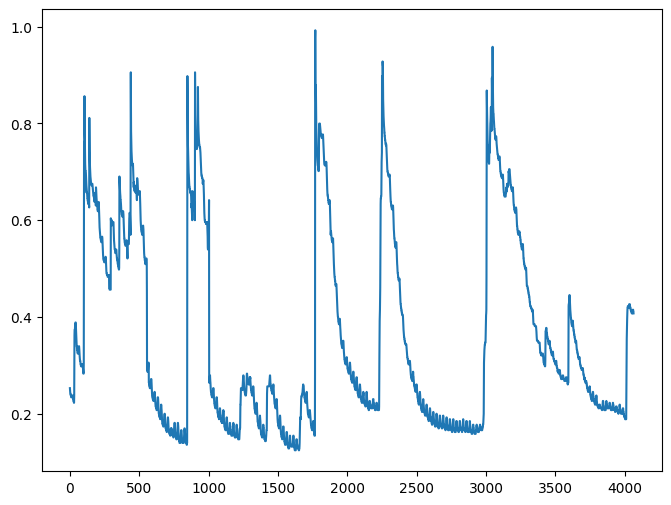

In [33]:
batch = 0   # First sequence in the batch.
signal = 0  # First signal from the 20 input-signals.
seq = x_batch[batch, :, signal]
plt.plot(seq)

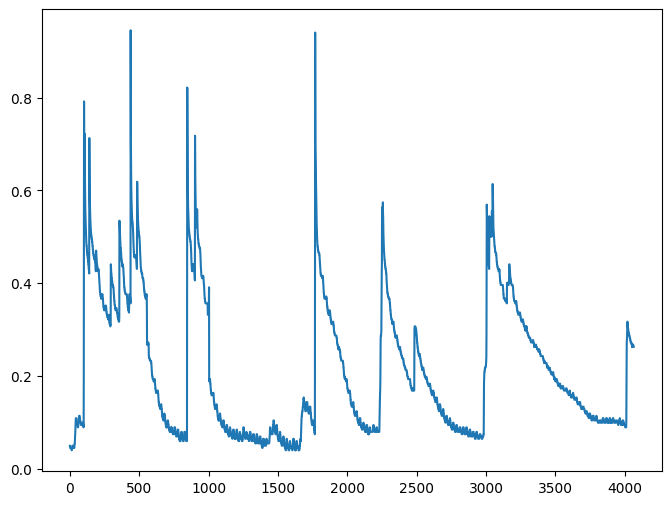

In [34]:
seq = y_batch[batch, :, signal]
plt.plot(seq)


In [35]:
validation_data = (np.expand_dims(x_test, axis=0),
                   np.expand_dims(y_test, axis=0))

validation_data[0].shape

(1, 4517, 18)

In [48]:
x_test.shape

(4517, 18)

# Making and Training RNN Model

In [36]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, GRU, Embedding
from tensorflow.keras.optimizers import RMSprop
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, TensorBoard, ReduceLROnPlateau
from tensorflow.keras.backend import square, mean

In [37]:
#make a function soon

model = Sequential()

model.add(GRU(units=512,
              return_sequences=True,
              input_shape=(None, num_x_signals,)))
model.add(Dense(num_y_signals, activation='sigmoid'))

if False:
    from tensorflow.python.keras.initializers import RandomUniform

    # Maybe use lower init-ranges.
    init = RandomUniform(minval=-0.05, maxval=0.05)

    model.add(Dense(num_y_signals,
                    activation='linear',
                    kernel_initializer=init))

In [38]:
warmup_steps = 50

In [39]:

# Custom Loss Function

def loss_mse_warmup(y_true, y_pred):
    """
    Calculate the Mean Squared Error between y_true and y_pred,
    but ignore the beginning "warmup" part of the sequences.

    y_true is the desired output.
    y_pred is the model's output.
    """

    # The shape of both input tensors are:
    # [batch_size, sequence_length, num_y_signals].

    # Ignore the "warmup" parts of the sequences
    # by taking slices of the tensors.
    y_true_slice = y_true[:, warmup_steps:, :]
    y_pred_slice = y_pred[:, warmup_steps:, :]

    # These sliced tensors both have this shape:
    # [batch_size, sequence_length - warmup_steps, num_y_signals]

    # Calculat the Mean Squared Error and use it as loss.
    mse = mean(square(y_true_slice - y_pred_slice))

    return mse

In [40]:
# Compile/Optimize

optimizer = RMSprop(learning_rate=1e-3)

model.compile(loss=loss_mse_warmup, optimizer=optimizer)

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 gru (GRU)                   (None, None, 512)         817152    
                                                                 
 dense (Dense)               (None, None, 1)           513       
                                                                 
Total params: 817,665
Trainable params: 817,665
Non-trainable params: 0
_________________________________________________________________


In [41]:
# Callback Functions

path_checkpoint = '23_checkpoint.keras'

callback_checkpoint = ModelCheckpoint(filepath=path_checkpoint,
                                      monitor='val_loss',
                                      verbose=1,
                                      save_weights_only=True,
                                      save_best_only=True)

callback_early_stopping = EarlyStopping(monitor='val_loss',
                                        patience=5, verbose=1)

callback_tensorboard = TensorBoard(log_dir='./23_logs/',
                                   histogram_freq=0,
                                   write_graph=False)


callback_reduce_lr = ReduceLROnPlateau(monitor='val_loss',
                                       factor=0.1,
                                       min_lr=1e-4,
                                       patience=0,
                                       verbose=1)

callbacks = [callback_early_stopping,
             callback_checkpoint,
             callback_tensorboard,
             callback_reduce_lr]

In [43]:
# Training

%%time
model.fit(x=generator,
          epochs=3,
          steps_per_epoch=1,
          validation_data=validation_data,
          callbacks=callbacks)

Epoch 1/3
1/1 [==============================] - ETA: 0s - loss: 0.0505
Epoch 1: val_loss did not improve from inf

Epoch 1: ReduceLROnPlateau reducing learning rate to 0.00010000000474974513.
1/1 [==============================] - 40s 40s/step - loss: 0.0505 - val_loss: nan - lr: 0.0010
Epoch 2/3
1/1 [==============================] - ETA: 0s - loss: 0.4318
Epoch 2: val_loss did not improve from inf

Epoch 2: ReduceLROnPlateau reducing learning rate to 0.0001.
1/1 [==============================] - 29s 29s/step - loss: 0.4318 - val_loss: nan - lr: 1.0000e-04
Epoch 3/3
1/1 [==============================] - ETA: 0s - loss: 0.4746
Epoch 3: val_loss did not improve from inf
1/1 [==============================] - 30s 30s/step - loss: 0.4746 - val_loss: nan - lr: 1.0000e-04
CPU times: user 1min 45s, sys: 4.76 s, total: 1min 50s
Wall time: 1min 39s


In [44]:
# Checkpoint loading

try:
    model.load_weights(path_checkpoint)
except Exception as error:
    print("Error trying to load checkpoint.")
    print(error)

Error trying to load checkpoint.
Cannot assign value to variable ' gru/gru_cell/kernel:0': Shape mismatch.The variable shape (18, 1536), and the assigned value shape (96, 1536) are incompatible.


# Model Evaluation

In [45]:
result = model.evaluate(x=np.expand_dims(x_test, axis=0),
                        y=np.expand_dims(y_test, axis=0))

# If you have several metrics you can use this instead.
if False:
    for res, metric in zip(result, model.metrics_names):
        print("{0}: {1:.3e}".format(metric, res))

1/1 [==============================] - 1s 1s/step - loss: nan
